## Problem Statement

Financial markets are noisy and predicting short-term price movements is difficult.
This project explores whether simple historical return features can help predict
the next-day/week/month return of a stock using Linear Regression.

Goal:
Evaluate whether past returns contain any predictive signal for future returns.

Dataset:
Daily stock price data downloaded using Yahoo Finance.

Target Variable:
Next-day/week/month return.

Model:
Linear Regression baseline model.

Evaluation Metrics:
Mean Squared Error (MSE) and R².

In [79]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from matplotlib import pyplot as plt
import numpy as np
import seaborn as sns
import yfinance as yf

In [80]:
ticker = ["RELIANCE.NS"]
start_date = "2018-05-01"
end_date = "2026-02-18"
df = yf.download(ticker, start=start_date, end=end_date)
# Flatten the MultiIndex columns by dropping the second level (Ticker name)
df.columns = df.columns.droplevel(level=1)


/tmp/ipykernel_369/2270840038.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [81]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1928 entries, 2018-05-02 to 2026-02-17
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1928 non-null   float64
 1   High    1928 non-null   float64
 2   Low     1928 non-null   float64
 3   Open    1928 non-null   float64
 4   Volume  1928 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 90.4 KB


In [82]:
df['return'] = df['Close'].pct_change()
df['target'] = df['return'].shift(-1)
df.head()

Price,Close,High,Low,Open,Volume,return,target
Date,,,,,,,
2018-05-02,429.671753,432.542981,426.292489,427.153870,13381914,NaN,-0.011411
2018-05-03,424.768585,431.968802,423.730517,431.968802,8634812,-0.011411,-0.007956
2018-05-04,421.389313,426.137904,419.644466,425.320695,8302649,-0.007956,0.017873
2018-05-07,428.920837,429.914733,422.449485,423.553811,7683268,0.017873,-0.004016
2018-05-08,427.198120,433.779932,426.358826,431.792140,10792648,-0.004016,0.009926


In [83]:
train_data, test_data = train_test_split(df, test_size=0.2, shuffle=False)

In [84]:
model = LinearRegression()

# Drop rows with NaN values in 'Daily Return' from the training data
train_data_cleaned = train_data.dropna(subset=['return'])
test_data_cleaned = test_data.dropna(subset=['target'])

# Now fit the model using the cleaned training data
# Note: Predicting 'Date' might not be the intended use case for a regression model.
# If you meant to predict 'Daily Return' or another numerical column, please specify.
model.fit(train_data_cleaned[['return']], train_data_cleaned['target'])

LinearRegression()

In [85]:
train_pred = model.predict(train_data_cleaned[['return']])
test_pred = model.predict(test_data_cleaned[['return']])


In [86]:
y_train = train_data_cleaned['target']
y_test = test_data_cleaned['target']

In [87]:
from sklearn.metrics import mean_squared_error, r2_score
print("Train MSE:", mean_squared_error(y_train, train_pred))
print("Test MSE:", mean_squared_error(y_test, test_pred))

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

Train MSE: 0.00035006235357989545
Test MSE: 0.0001604098551857654
Train R2: 0.0011000563201178926
Test R2: -0.01254062756260721


Question: What does this value suggest on daily return basis?

Answer:
1. Train RMSE = 1.87% and Test RMSE = 1.26% suggests that predictions are close to zero.

2. R2 values for train is almost 0 and for test it is slightly negative which suggests that model is predicting no useful signal.

### Weekly

In [88]:
df = yf.download(ticker, start=start_date, end=end_date)
# Flatten the MultiIndex columns by dropping the second level (Ticker name)
df.columns = df.columns.droplevel(level=1)

/tmp/ipykernel_369/851556473.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [89]:
#df['Date'] = pd.to_datetime(df['Price Date'])
#df = df.set_index('Date')
weekly_data = df['Close'].resample('W').last()

In [90]:
weekly_data = weekly_data.to_frame()
weekly_price = weekly_data.pct_change()
weekly_price['target'] = weekly_price['Close'].shift(-1)
weekly_price.head()

,Close,target
Date,,
2018-05-06,NaN,0.037004
2018-05-13,0.037004,-0.056002
2018-05-20,-0.056002,-0.013974
2018-05-27,-0.013974,0.010589
2018-06-03,0.010589,0.057815


In [91]:
train_data, test_data = train_test_split(weekly_price, test_size=0.2, shuffle=False)

In [92]:
train_data_cleaned = train_data.dropna(subset=['Close'])
test_data_cleaned = test_data.dropna(subset=['target'])

In [93]:
model.fit(train_data_cleaned[['Close']], train_data_cleaned['target'])

LinearRegression()

In [94]:
train_pred = model.predict(train_data_cleaned[['Close']])
test_pred = model.predict(test_data_cleaned[['Close']])

In [95]:
y_train = train_data_cleaned['target']
y_test = test_data_cleaned['target']

In [96]:
print("Train MSE:", mean_squared_error(y_train, train_pred))
print("Test MSE:", mean_squared_error(y_test, test_pred))

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

#print("Train Mean:", train_data_cleaned['Close'].mean())
#print("Test Mean:", test_data_cleaned['Close'].mean())

Train MSE: 0.0014581809381806346
Test MSE: 0.0008868779138837424
Train R2: 7.658705911717245e-05
Test R2: -0.026120773110139606


Question: What does these values suggest on weekly return basis?

Answer:

Train RMSE = 3.81% and Test RMSE = 2.97% suggests that predictions are close to zero.

R2 values for train is almost 0 and for test it is slightly negative which suggests that model is predicting no useful signal.

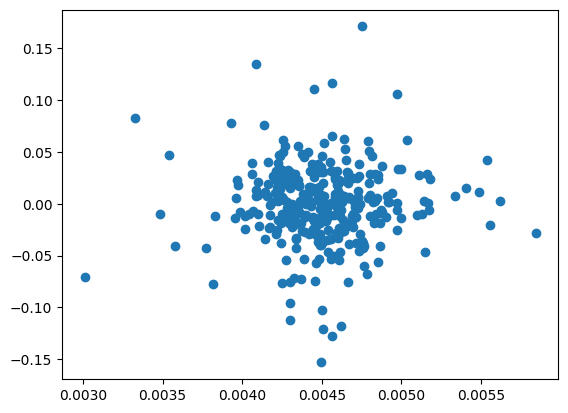

In [97]:
residuals = train_pred - y_train
plt.scatter(train_pred, residuals)

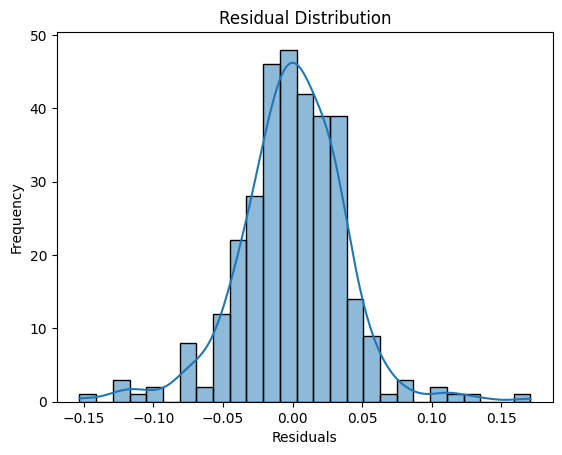

In [98]:
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.title("Residual Distribution")
plt.show()

Plot 1:


*   Residuals are centered around 0, so errors are roughly unbiased
*   Presence of some outliers indicates large errors, possiblities can be large market movements or model unable to predict large outcomes

Plot 2:


*   Residuals are following normal distribution which follows assumption of Linear regression






### Monthly Basis

In [99]:
df = yf.download(ticker, start=start_date, end=end_date)
# Flatten the MultiIndex columns by dropping the second level (Ticker name)
df.columns = df.columns.droplevel(level=1)

/tmp/ipykernel_369/851556473.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [100]:
#df['Date'] = pd.to_datetime(df['Date'])
#df = df.set_index('Date')
monthly_data = df['Close'].resample('M').last()

/tmp/ipykernel_369/2686612204.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_data = df['Close'].resample('M').last()


In [102]:
monthly_data = monthly_data.to_frame()
monthly_price = monthly_data.pct_change()
monthly_price['target'] = monthly_price['Close'].shift(-1)
monthly_price.head()

,Close,target
Date,,
2018-05-31,NaN,0.062518
2018-06-30,0.062518,0.219600
2018-07-31,0.219600,0.046923
2018-08-31,0.046923,0.013128
2018-09-30,0.013128,-0.156365


In [103]:
train_data, test_data = train_test_split(monthly_price, test_size=0.2, shuffle=False)

In [104]:
train_data_cleaned = train_data.dropna(subset=['Close'])
test_data_cleaned = test_data.dropna(subset=['target'])

In [105]:
model.fit(train_data_cleaned[['Close']], train_data_cleaned['target'])

LinearRegression()

In [106]:
train_pred = model.predict(train_data_cleaned[['Close']])
test_pred = model.predict(test_data_cleaned[['Close']])

In [107]:
y_train = train_data_cleaned['target']
y_test = test_data_cleaned['target']

In [108]:
print("Train MSE:", mean_squared_error(y_train, train_pred))
print("Test MSE:", mean_squared_error(y_test, test_pred))

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))

#print("Train Mean:", train_data_cleaned['Close'].mean())
#print("Test Mean:", test_data_cleaned['Close'].mean())

Train MSE: 0.006737667735178502
Test MSE: 0.004170479049718752
Train R2: 0.0005893052021397338
Test R2: -0.13746696159617477


In [109]:
np.corrcoef(test_pred,y_test)[0,1]

np.float64(-0.11182345912564085)

Learning from daily, weekly and MOnthly predictions:

*   R2 Negative = Model capture no signal
*   Test R2 Negative = slightly worse than mean predictor
*   Train R² very low = Model unable to fit training data
*   correlation coefficient suggest that there is very smal but useful correlation between prediction and actual resutls








## Feature Engineering

Financial markets often exhibit short-term patterns such as momentum and volatility clustering.
To capture these effects, the following features are created:

1. Daily return
2. 5-day momentum
3. 5-day moving average
4. 10-day moving average
5. 5-day rolling volatility

In [113]:
df = yf.download(ticker, start=start_date, end=end_date)
# Flatten the MultiIndex columns by dropping the second level (Ticker name)
df.columns = df.columns.droplevel(level=1)

/tmp/ipykernel_369/851556473.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start_date, end=end_date)
[*********************100%***********************]  1 of 1 completed


In [138]:
# Daily return
df["return"] = df["Close"].pct_change()

# Momentum
df["momentum_5"] = df["Close"].pct_change(5) #Momentum measures recent trend strength

# Moving averages
df["ma_5"] = df["Close"].rolling(5).mean() # smooths short-term noise
df["ma_10"] = df["Close"].rolling(10).mean() #compares short vs medium trend
df["ma_ratio"] = df["ma_5"] / df["ma_10"] # as use of both ma_5 and ma_10 can create high correlation

# Rolling volatility
df["volatility_5"] = df["return"].rolling(5).std() #markets show volatility clustering

# Target (next day return)
df["target"] = df["return"].shift(-1)

# Drop missing values
df = df.dropna()


<Axes: xlabel='Price', ylabel='Price'>

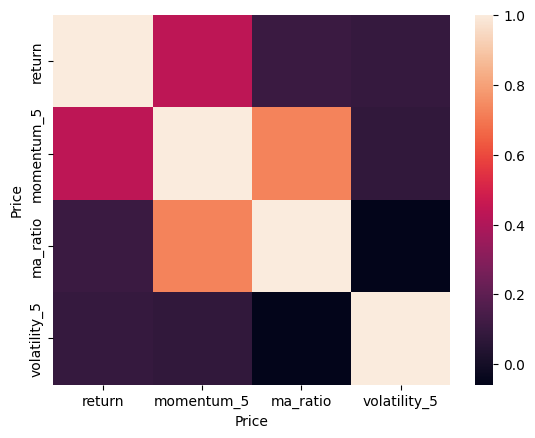

In [145]:
sns.heatmap(df[features].corr())

*   ma_ratio vs volatility_5 appears slightly negative
    
    Reason:
    
    strong trends → smoother price movement → lower volatility

    chaotic markets → high volatility → weak trends



In [139]:
features = ["return","momentum_5","ma_ratio","volatility_5"]
x= df[features]
y = df["target"]

In [140]:
x_train,x_test,y_train,y_test = train_test_split(x,y, test_size=0.2, shuffle=False)
x_train = x_train.dropna()
x_test = x_test.dropna()
y_train = y_train.dropna()
y_test = y_test.dropna()

In [141]:
model.fit(x_train,y_train)

LinearRegression()

In [142]:
train_pred = model.predict(x_train)
test_pred = model.predict(x_test)

In [143]:
print("Train MSE:", mean_squared_error(y_train, train_pred))
print("Test MSE:", mean_squared_error(y_test, test_pred))

print("Train R2:", r2_score(y_train, train_pred))
print("Test R2:", r2_score(y_test, test_pred))


print("Correlation:", np.corrcoef(y_test, test_pred)[0,1])


Train MSE: 0.00035214191066804926
Test MSE: 0.0001577556477692824
Train R2: 0.004044735964396251
Test R2: -0.011425624267043633
Correlation: -0.06372676941079924


Text(0.5, 1.0, 'Actual vs Predicted Returns')

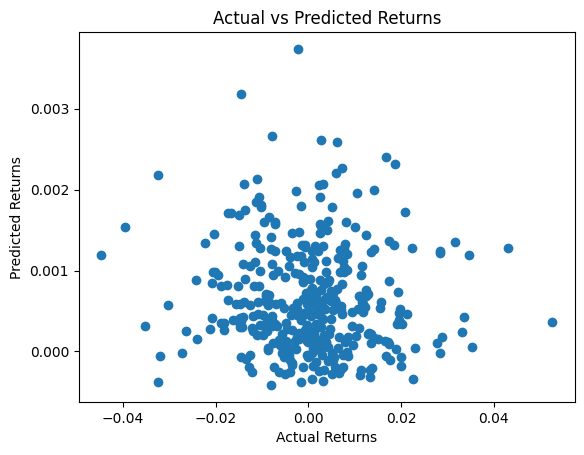

In [147]:
plt.scatter(y_test, test_pred)
plt.xlabel("Actual Returns")
plt.ylabel("Predicted Returns")
plt.title("Actual vs Predicted Returns")

## Results Interpretation

The model produces a very low R² value, indicating that past returns have very
limited predictive power for next-day returns.

*   Prediction values: -0.0005 to 0.0035 and Actual return: -0.04 to 0.05
*   model predict very small values and no clear diagonal structure


This result is expected in financial markets because:
- Markets are highly efficient.
- Noise in short-term movements can lead to low prediction ability.
- Linear relationships between past and future returns are weak.
